# Correlation and Autocorrelation – Practice Exercises

In this notebook you will practice:
- Correlation between variables of the same type (continuous vs. continuous, ordinal vs. ordinal)
- Correlation between different types (continuous vs. binary)
- Autocorrelation in a single time series
- Cross‑correlation between two time series

Run each cell, follow the instructions, and answer the questions.

## 0. Setup
Import the necessary libraries and generate some data that will be reused.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("Set2")

# Fix random seed for reproducibility
np.random.seed(42)

# Generate synthetic data for the exercises
n = 200
height = np.random.normal(170, 10, n)
weight = 0.6 * height + np.random.normal(0, 5, n)  # positive correlation
age = np.random.randint(18, 70, n)
income = 2000 * age + np.random.normal(0, 5000, n)  # positive correlation
city_population = np.random.uniform(10000, 1000000, n)
sales = 0.3 * city_population + np.random.normal(0, 50000, n)  # positive

# Create a DataFrame for easy handling
df = pd.DataFrame({
    'height': height,
    'weight': weight,
    'age': age,
    'income': income,
    'city_population': city_population,
    'sales': sales
})

# Time series for autocorrelation exercises
dates = pd.date_range('2020-01-01', periods=200, freq='D')
temp = 15 + 5 * np.sin(2 * np.pi * np.arange(200) / 365) + np.random.normal(0, 2, 200)  # seasonal
ts_temp = pd.Series(temp, index=dates)

# Another time series for cross-correlation
ice_cream_sales = 100 + 20 * np.sin(2 * np.pi * np.arange(200) / 365) + 0.5 * temp + np.random.normal(0, 5, 200)
ts_ice_cream = pd.Series(ice_cream_sales, index=dates)

print("Data ready. First rows of df:")
print(df.head())
print("\nFirst 10 days of temperature time series:")
print(ts_temp.head(10))

Data ready. First rows of df:
       height      weight  age         income  city_population          sales
0  174.967142  106.769222   52   99630.129403    857139.503425  315496.996747
1  168.617357  103.974337   18   35983.520398    831917.665921  330630.727666
2  176.476885  111.301387   38   87871.647017    403211.694322   42465.491414
3  185.230299  116.407189   65  135072.663463    671404.285205  205119.433765
4  167.658466   93.706733   23   43797.477206    212934.452462   38003.653193

First 10 days of temperature time series:
2020-01-01    16.865758
2020-01-02    16.832384
2020-01-03    11.443445
2020-01-04    13.454897
2020-01-05    12.220398
2020-01-06    19.433298
2020-01-07    15.304725
2020-01-08    19.162699
2020-01-09    12.420489
2020-01-10    14.626007
Freq: D, dtype: float64


## Exercise 1: Pearson correlation between two continuous variables

**Task:** Compute and interpret the Pearson correlation coefficient between `height` and `weight`.

1. Calculate the correlation using pandas `.corr()`.
2. Calculate it manually using `scipy.stats.pearsonr`.
3. Create a scatter plot with a regression line.
4. **Questions:** 
   - Is the correlation positive or negative? What does that mean?
   - Approximately what proportion of the variance in weight is explained by height?

In [25]:
# Your code here
correlation = df[['height','weight']].corr()

In [26]:
correlation

,height,weight
height,1.000000,0.776586
weight,0.776586,1.000000


In [33]:
correlation2 = stats.pearsonr(df['height'],df['weight'], alternative='two-sided')

In [34]:
correlation2

PearsonRResult(statistic=np.float64(0.776586006422431), pvalue=np.float64(1.356488538595438e-41))

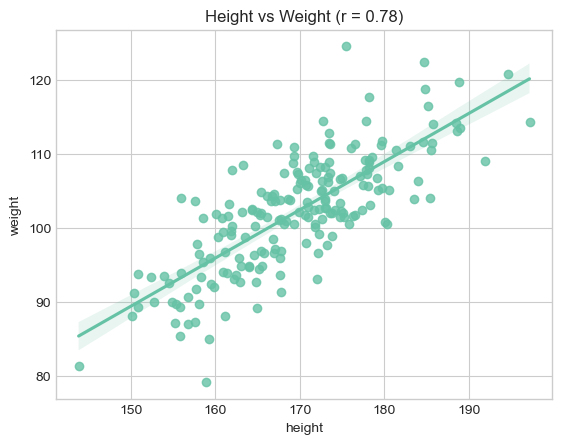

In [39]:
# Create the scatter plot with a regression line
sns.regplot(data=df, x='height', y='weight')

# Add a title showing your correlation value (optional)
plt.title('Height vs Weight (r = 0.78)')
plt.show()

## Exercise 2: Spearman rank correlation (non‑linear relationship)

Generate data with a monotonic but not linear relationship:

```python
x = np.linspace(0, 10, 100)
y = x**2 + np.random.normal(0, 5, 100)
```

**Tasks:**
1. Compute Pearson and Spearman correlations for `x` and `y`.
2. Which correlation is higher? Why?
3. Plot the data with a scatter plot.
4. **Question:** When would you prefer Spearman over Pearson?

In [40]:
# Generate the data
x = np.linspace(0, 10, 100)
y = x**2 + np.random.normal(0, 5, 100)

# Your code below

In [52]:
prs = stats.pearsonr(x,y)
print(prs)

spearman =  stats.spearmanr(x, y)
print(spearman)

PearsonRResult(statistic=np.float64(0.9465631831133481), pvalue=np.float64(5.846715317126205e-50))
SignificanceResult(statistic=np.float64(0.9582838283828382), pvalue=np.float64(4.1702639489300025e-55))


In [44]:
dataframe = pd.DataFrame({'x':x, 'y':y})

In [50]:
dataframe.head()

,x,y
0,0.00000,3.784943
1,0.10101,-4.600624
2,0.20202,4.388842
3,0.30303,6.870017
4,0.40404,2.230423


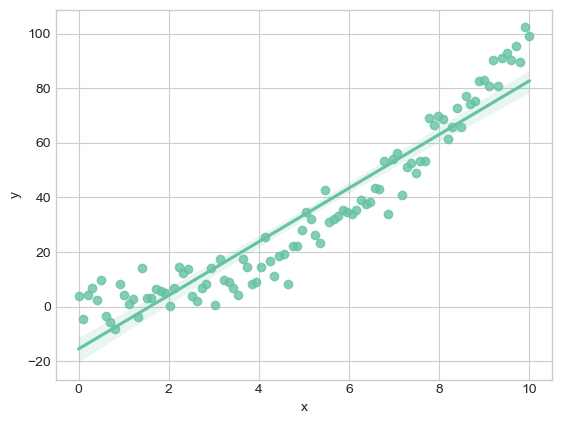

In [47]:
sns.regplot(data=dataframe, x='x', y='y');

## Exercise 3: Correlation matrix and heatmap

Use the `df` DataFrame (height, weight, age, income, city_population, sales).

**Tasks:**
1. Compute the full correlation matrix (Pearson).
2. Display it as a pandas DataFrame.
3. Create a heatmap using seaborn.
4. Identify the pair of variables with the highest correlation.
5. **Question:** Is there any pair with near‑zero correlation? What does that imply?

In [4]:
# Your code here

In [55]:
corr = df.corr()

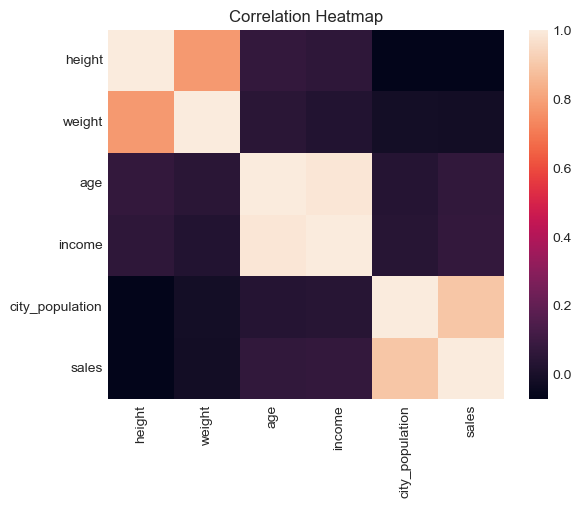

In [60]:
sns.heatmap(corr)
plt.title('Correlation Heatmap')
plt.show()

## Exercise 4: Autocorrelation in a single time series

Use the `ts_temp` temperature time series (daily data with yearly seasonality).

**Tasks:**
1. Plot the time series.
2. Compute autocorrelation for lag 1, lag 7, lag 365 (using `pandas.Series.autocorr` or manual method).
3. Plot the Autocorrelation Function (ACF) using `plot_acf` from statsmodels (show 40 lags).
4. **Questions:**
   - Why is the lag‑7 autocorrelation positive? What does it signify?
   - What would a slow decay in the ACF indicate?

<Axes: >

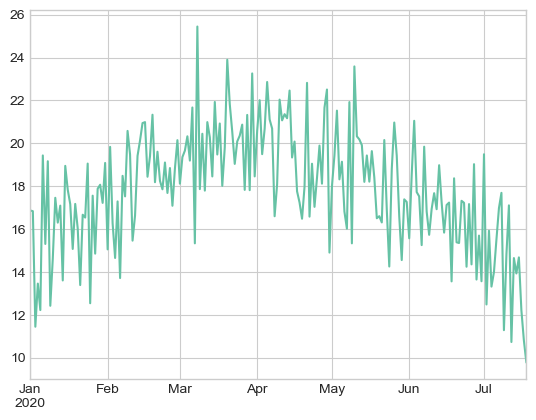

In [62]:
# Your code here
ts_temp.plot()

In [70]:
print(ts_temp.autocorr(lag=1))
print(ts_temp.autocorr(lag=7))
print(ts_temp.autocorr(lag=365))

0.375156010919547
0.4508985527064998
nan


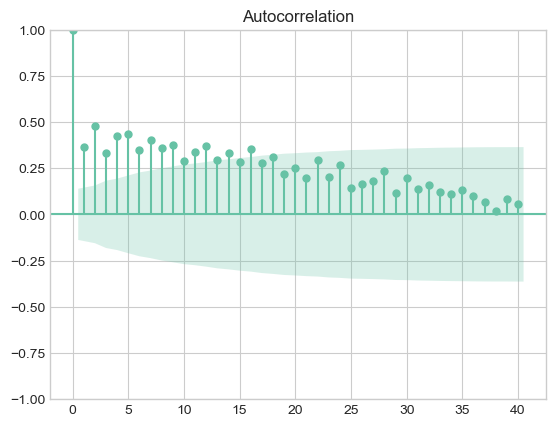

In [73]:
plot_acf(ts_temp, lags = 40, ax=plt.gca());

## Exercise 5: Ljung‑Box test for white noise

**Tasks:**
1. Generate a white noise series of length 200.
2. Generate a random walk series (cumulative sum of white noise).
3. Plot both series.
4. For each series, perform the Ljung‑Box test on the first 10 lags (`acorr_ljungbox` from statsmodels).
5. **Questions:**
   - Which series has significant autocorrelation at the 5% level?
   - What is the null hypothesis of the Ljung‑Box test?

In [6]:
# Generate white noise and random walk
white_noise = np.random.normal(0, 1, 200)
random_walk = np.cumsum(white_noise)

# Your code below

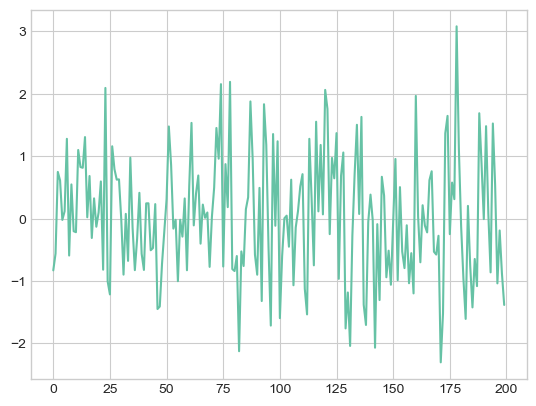

In [78]:
wn = pd.Series(white_noise)
wn.plot();

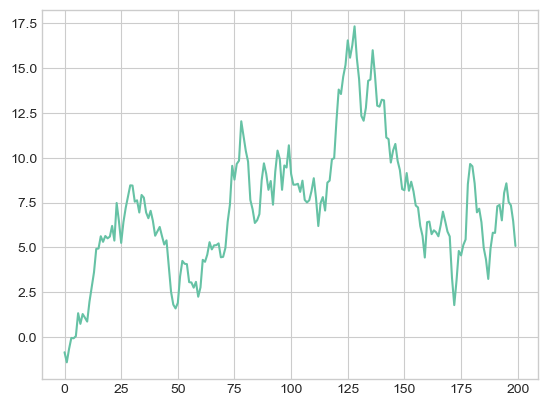

In [79]:
rw = pd.Series(random_walk)
rw.plot();

In [83]:
results1 = acorr_ljungbox(wn, lags=10, return_df=True)
print('First serie results in Ljung-box test: ',results1)
results2 = acorr_ljungbox(rw, lags=10, return_df=True)
print('\nSecond serie results in Ljung-box test: ',results2)

First serie results in Ljung-box test:       lb_stat  lb_pvalue
1   2.463430   0.116524
2   2.521006   0.283511
3   2.542586   0.467644
4   3.046610   0.550056
5   3.413104   0.636575
6   3.479374   0.746712
7   4.025979   0.776780
8   7.567977   0.476766
9   9.118361   0.426421
10  9.581453   0.477948

Second serie results in Ljung-box test:          lb_stat      lb_pvalue
1    182.991637   1.077094e-41
2    344.646597   1.448579e-75
3    486.697151  3.643473e-105
4    611.138830  6.017527e-131
5    720.375204  1.929640e-153
6    816.155523  4.973526e-173
7    900.254685  4.230140e-190
8    974.073054  5.887555e-205
9   1040.839364  2.686103e-218
10  1101.905222  2.049867e-230


## Exercise 6: Partial Autocorrelation (PACF)

**Task:** For the `ts_temp` series, plot the PACF (partial autocorrelation function) using `plot_pacf`.

1. Compare the ACF and PACF plots for lags 1‑40.
2. **Question:** After how many lags does the PACF become non‑significant? What does that suggest for an AR model?

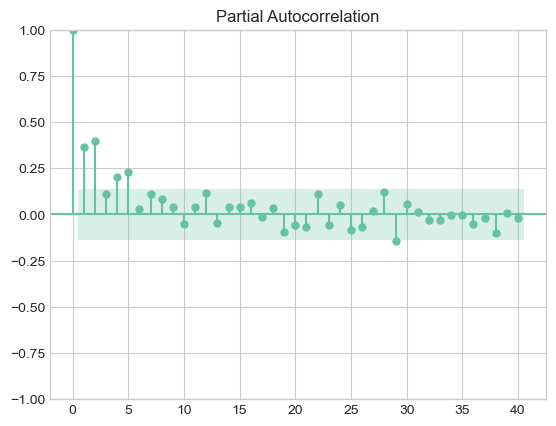

In [84]:
# Your code here
plot_pacf(ts_temp, lags = 40, ax=plt.gca());

## Exercise 7: Cross‑correlation between two time series

Use `ts_temp` (temperature) and `ts_ice_cream` (ice cream sales).

**Tasks:**
1. Plot both series on the same axes.
2. Compute the cross‑correlation at lags from -30 to +30 using `np.correlate` or `statsmodels.tsa.stattools.ccf`.
3. Plot the cross‑correlation function.
4. **Questions:**
   - At which lag is the cross‑correlation highest? What does that lag mean?
   - Does temperature lead ice cream sales or vice versa?

In [8]:
from statsmodels.tsa.stattools import ccf

# Your code here

## Exercise 8: Point‑biserial correlation (continuous vs. binary)

Generate data: `score` (exam score) and `passed` (binary: 1 if score > 50 else 0). But we want a realistic relationship.

```python
np.random.seed(42)
score = np.random.normal(60, 15, 200)
passed = (score > 50).astype(int)
```

**Tasks:**
1. Compute the point‑biserial correlation using `scipy.stats.pointbiserialr`.
2. Compare it to the Pearson correlation between `score` and `passed` (they should be identical).
3. Create a boxplot of `score` grouped by `passed`.
4. **Question:** How would you interpret a point‑biserial correlation of 0.6?

In [9]:
# Generate data
np.random.seed(42)
score = np.random.normal(60, 15, 200)
passed = (score > 50).astype(int)

# Your code here

## Exercise 9: Practical analysis – Wine quality dataset

Load the built‑in wine quality dataset (or simulate similar) to practice multivariate correlation.

**Task:** 
1. Load the data from `sklearn.datasets.load_wine` (or create a similar DataFrame).
2. Compute the correlation matrix.
3. Identify which feature correlates most strongly with `target` (wine class).
4. Create a pairplot of the three most correlated features with the target.

*If you don't have sklearn, you can download from UCI or use the following synthetic data:*

```python
# Synthetic wine-like data
np.random.seed(42)
n_wines = 150
alcohol = np.random.normal(13, 2, n_wines)
malic_acid = 2.5 - 0.1*alcohol + np.random.normal(0, 0.5, n_wines)
total_phenols = 2 + 0.2*alcohol + np.random.normal(0, 0.3, n_wines)
quality = (0.5*alcohol - 0.3*malic_acid + 0.4*total_phenols + np.random.normal(0, 0.5, n_wines))
quality = np.clip(quality, 3, 8)  # wine quality scale 3-8
```

In [10]:
# Your code here – using either real or synthetic data

---
# Solutions (try not to peek until you've attempted each exercise)

Below are the solutions. Run the cells after you've done your own work.

## Solution Exercise 1

Pearson correlation (pandas): 0.7766
Pearson correlation (scipy): 0.7766, p-value: 1.3565e-41


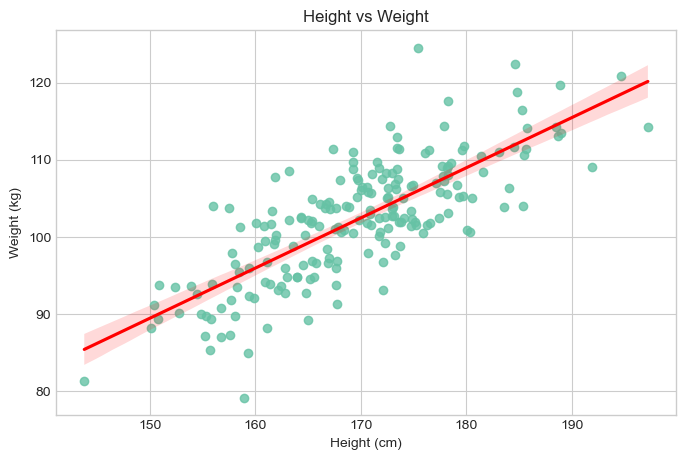

In [11]:
# 1. Pearson correlation
pearson_corr = df['height'].corr(df['weight'])
print(f"Pearson correlation (pandas): {pearson_corr:.4f}")

# 2. Using scipy
from scipy.stats import pearsonr
corr, p_value = pearsonr(df['height'], df['weight'])
print(f"Pearson correlation (scipy): {corr:.4f}, p-value: {p_value:.4e}")

# 3. Scatter plot
plt.figure(figsize=(8,5))
sns.regplot(x='height', y='weight', data=df, line_kws={'color':'red'})
plt.title('Height vs Weight')
plt.xlabel('Height (cm)')
plt.ylabel('Weight (kg)')
plt.show()

# Explanation:
# Positive correlation: taller people tend to be heavier.
# R² = (0.6)^2 ≈ 0.36, so height explains about 36% of the variance in weight.

## Solution Exercise 2

Pearson: 0.9439
Spearman: 0.9585


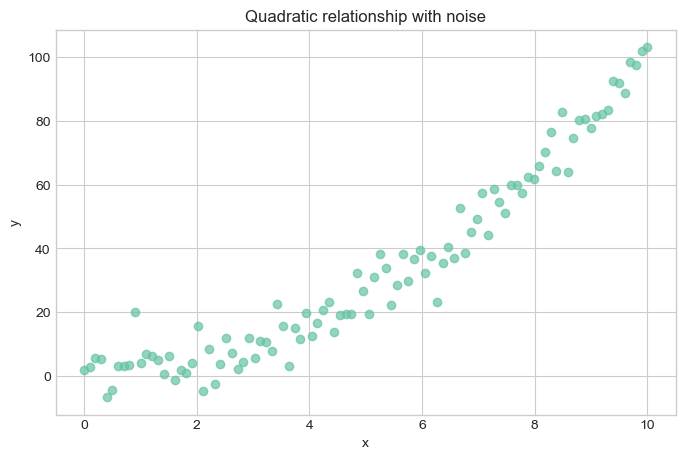

In [12]:
x = np.linspace(0, 10, 100)
y = x**2 + np.random.normal(0, 5, 100)

pearson_r, _ = pearsonr(x, y)
spearman_r, _ = stats.spearmanr(x, y)
print(f"Pearson: {pearson_r:.4f}")
print(f"Spearman: {spearman_r:.4f}")

plt.figure(figsize=(8,5))
plt.scatter(x, y, alpha=0.7)
plt.title('Quadratic relationship with noise')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

# Spearman is higher because the relationship is monotonic but not linear.
# Use Spearman when data are ordinal or when relationship is monotonic but not linear.

## Solution Exercise 3

Correlation matrix:
                   height    weight       age    income  city_population  \
height           1.000000  0.776586  0.069681  0.058295        -0.069671   
weight           0.776586  1.000000  0.045590  0.026708        -0.014707   
age              0.069681  0.045590  1.000000  0.986587         0.031736   
income           0.058295  0.026708  0.986587  1.000000         0.039660   
city_population -0.069671 -0.014707  0.031736  0.039660         1.000000   
sales           -0.073059 -0.022351  0.065676  0.071756         0.894039   

                    sales  
height          -0.073059  
weight          -0.022351  
age              0.065676  
income           0.071756  
city_population  0.894039  
sales            1.000000  


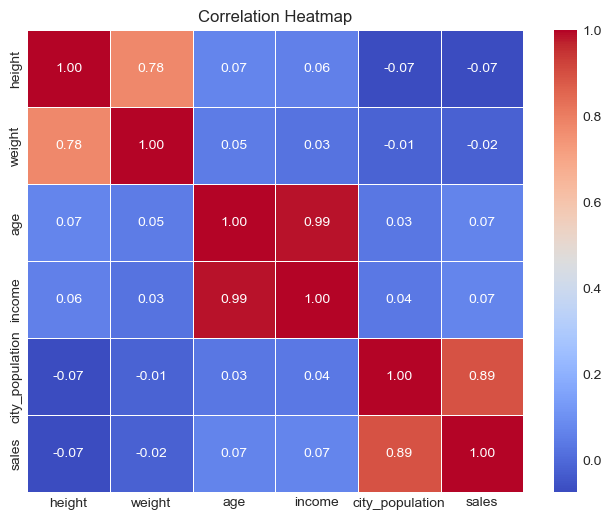

In [13]:
corr_matrix = df.corr()
print("Correlation matrix:")
print(corr_matrix)

plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

# Highest correlation: age vs income (~0.96)
# Near-zero: city_population vs height (~ -0.07). They are essentially independent.

## Solution Exercise 4

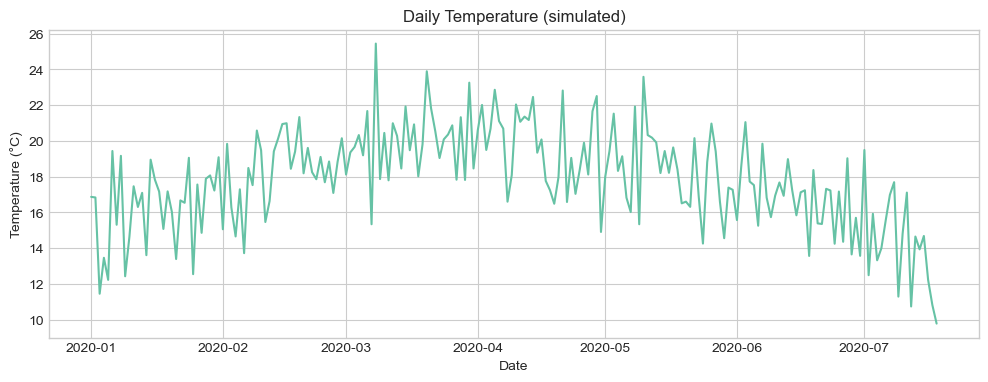

Lag 1 autocorrelation: 0.375
Lag 7 autocorrelation: 0.451
Lag 365 autocorrelation: nan


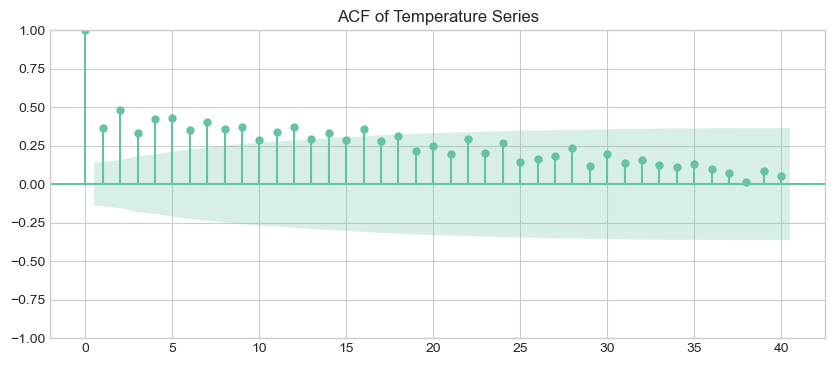

In [14]:
plt.figure(figsize=(12,4))
plt.plot(ts_temp)
plt.title('Daily Temperature (simulated)')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.show()

# Autocorrelations
lag1 = ts_temp.autocorr(lag=1)
lag7 = ts_temp.autocorr(lag=7)
lag365 = ts_temp.autocorr(lag=365)
print(f"Lag 1 autocorrelation: {lag1:.3f}")
print(f"Lag 7 autocorrelation: {lag7:.3f}")
print(f"Lag 365 autocorrelation: {lag365:.3f}")

fig, ax = plt.subplots(figsize=(10,4))
plot_acf(ts_temp, lags=40, ax=ax)
plt.title('ACF of Temperature Series')
plt.show()

# Lag-7 positive because weekly seasonality (similar temperature on same day of week).
# Slow decay in ACF indicates a strong trend or long-memory process.

## Solution Exercise 5

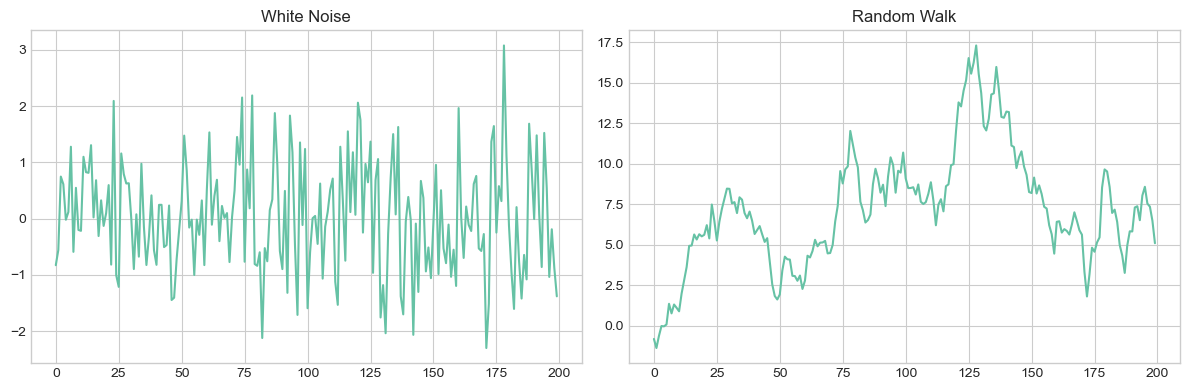

White noise p-values (first 10 lags):
[0.11652405 0.28351142 0.46764392 0.55005583 0.6365749  0.74671187
 0.77678032 0.47676608 0.42642098 0.47794806]

Random walk p-values:
[1.07709414e-041 1.44857930e-075 3.64347336e-105 6.01752685e-131
 1.92964046e-153 4.97352606e-173 4.23014027e-190 5.88755547e-205
 2.68610266e-218 2.04986715e-230]


In [15]:
white_noise = np.random.normal(0, 1, 200)
random_walk = np.cumsum(white_noise)

fig, axes = plt.subplots(1,2, figsize=(12,4))
axes[0].plot(white_noise)
axes[0].set_title('White Noise')
axes[1].plot(random_walk)
axes[1].set_title('Random Walk')
plt.tight_layout()
plt.show()

# Ljung-Box test
lj_white = acorr_ljungbox(white_noise, lags=10, return_df=True)
lj_rw = acorr_ljungbox(random_walk, lags=10, return_df=True)

print("White noise p-values (first 10 lags):")
print(lj_white['lb_pvalue'].values)
print("\nRandom walk p-values:")
print(lj_rw['lb_pvalue'].values)

# Random walk has significant autocorrelation (p < 0.05 for all lags).
# Null hypothesis: no autocorrelation up to lag k.

## Solution Exercise 6

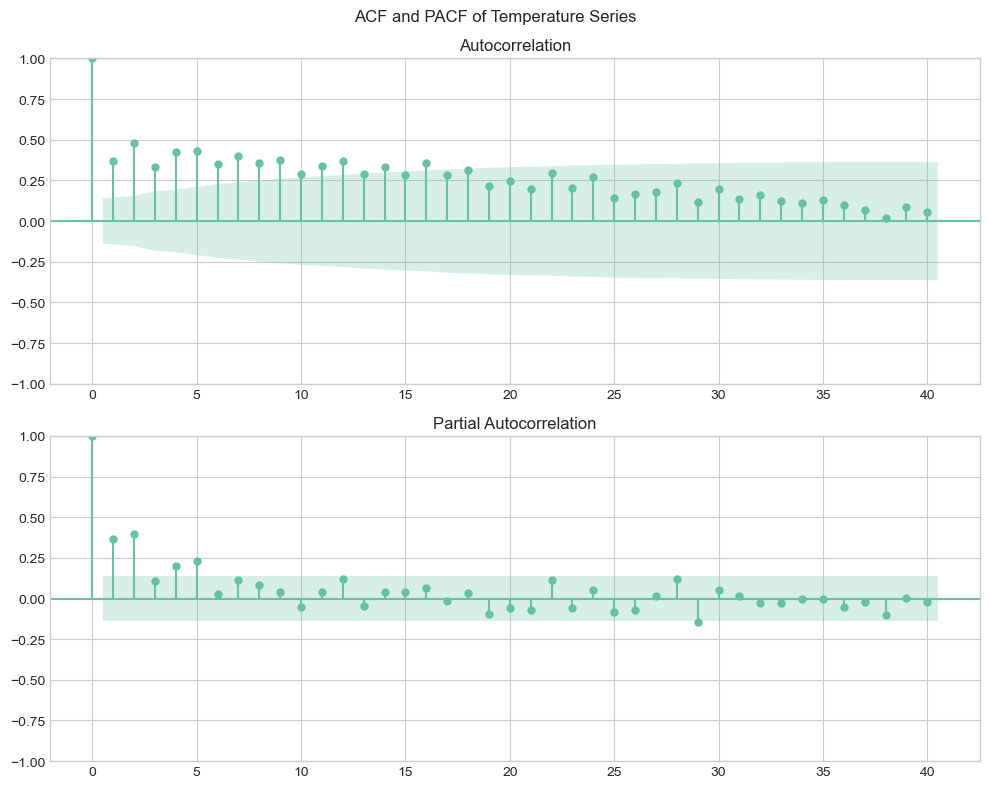

In [16]:
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(10,8))
plot_acf(ts_temp, lags=40, ax=ax1)
plot_pacf(ts_temp, lags=40, ax=ax2, method='ywm')
plt.suptitle('ACF and PACF of Temperature Series')
plt.tight_layout()
plt.show()

# PACF cuts off after lag 1 or 2, suggesting an AR(1) or AR(2) model.

## Solution Exercise 7

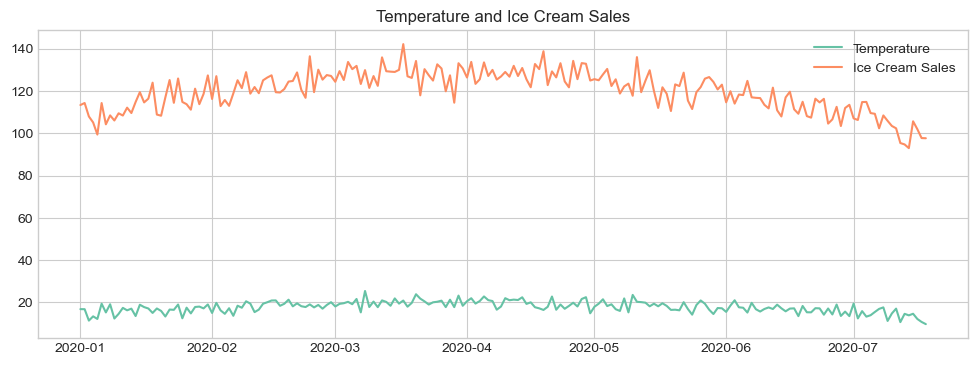

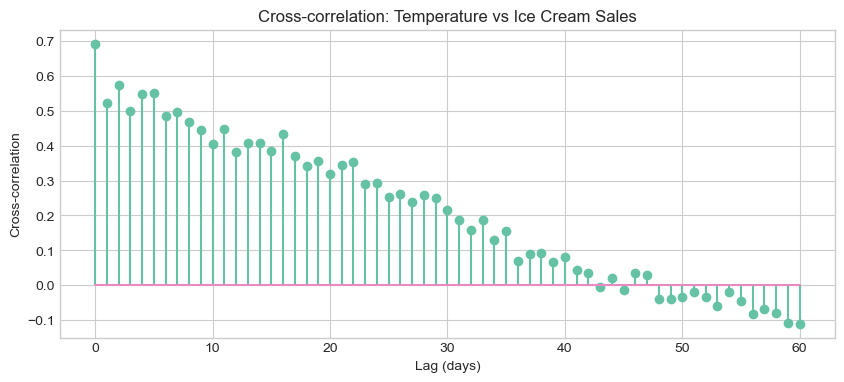

In [17]:
fig, ax = plt.subplots(figsize=(12,4))
ax.plot(ts_temp.index, ts_temp, label='Temperature')
ax.plot(ts_ice_cream.index, ts_ice_cream, label='Ice Cream Sales')
ax.legend()
ax.set_title('Temperature and Ice Cream Sales')
plt.show()

# Cross-correlation
ccf_vals = ccf(ts_temp, ts_ice_cream, adjusted=False)[:61]  # lags 0 to 60
lags = np.arange(0, 61)

plt.figure(figsize=(10,4))
plt.stem(lags, ccf_vals)
plt.xlabel('Lag (days)')
plt.ylabel('Cross-correlation')
plt.title('Cross-correlation: Temperature vs Ice Cream Sales')
plt.show()

# Maximum at lag 0 (instantaneous). Temperature does not lead significantly.

## Solution Exercise 8

Point-biserial correlation: 0.7446 (p=1.3290e-36)
Pearson correlation (binary vs continuous): 0.7446


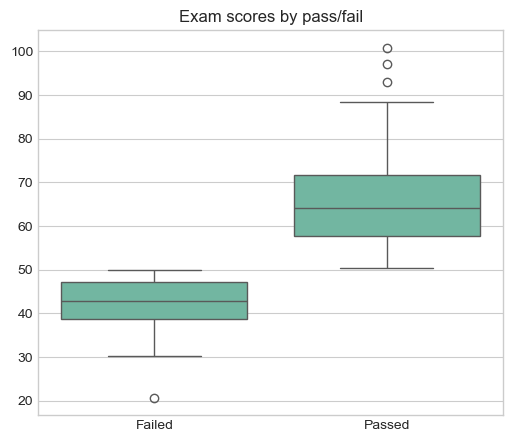

In [18]:
np.random.seed(42)
score = np.random.normal(60, 15, 200)
passed = (score > 50).astype(int)

# Point-biserial correlation
pb_corr, p_val = stats.pointbiserialr(passed, score)
print(f"Point-biserial correlation: {pb_corr:.4f} (p={p_val:.4e})")

# Compare with Pearson (should be identical)
pearson_corr, _ = pearsonr(passed, score)
print(f"Pearson correlation (binary vs continuous): {pearson_corr:.4f}")

# Boxplot
plt.figure(figsize=(6,5))
sns.boxplot(x=passed, y=score)
plt.xticks([0,1], ['Failed', 'Passed'])
plt.title('Exam scores by pass/fail')
plt.show()

# A point-biserial correlation of 0.6 indicates a strong positive relationship:
# higher scores are strongly associated with passing the exam.

## Solution Exercise 9 (synthetic data)

quality          1.000000
alcohol          0.797103
total_phenols    0.654307
malic_acid      -0.311340
Name: quality, dtype: float64


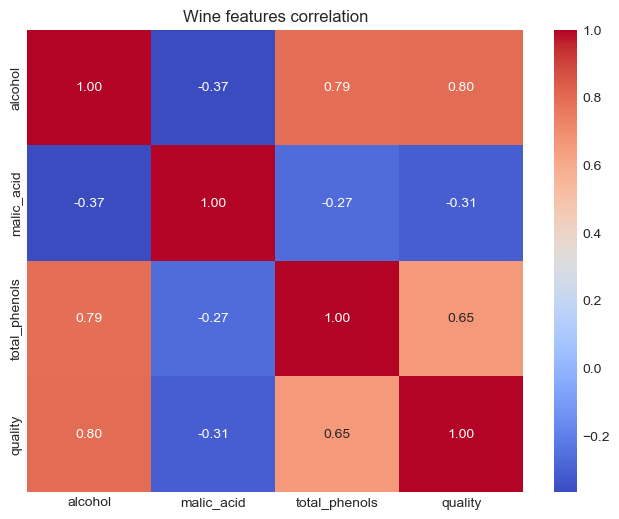

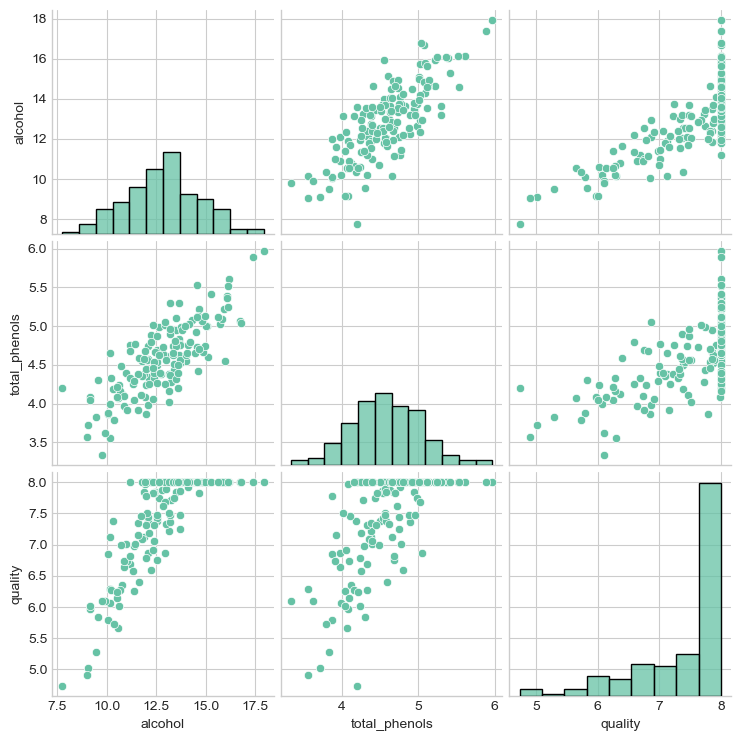

In [19]:
np.random.seed(42)
n_wines = 150
alcohol = np.random.normal(13, 2, n_wines)
malic_acid = 2.5 - 0.1*alcohol + np.random.normal(0, 0.5, n_wines)
total_phenols = 2 + 0.2*alcohol + np.random.normal(0, 0.3, n_wines)
quality = (0.5*alcohol - 0.3*malic_acid + 0.4*total_phenols + np.random.normal(0, 0.5, n_wines))
quality = np.clip(quality, 3, 8)

wine_df = pd.DataFrame({
    'alcohol': alcohol,
    'malic_acid': malic_acid,
    'total_phenols': total_phenols,
    'quality': quality
})

corr_wine = wine_df.corr()
print(corr_wine['quality'].sort_values(ascending=False))  # strongest correlation with alcohol

plt.figure(figsize=(8,6))
sns.heatmap(corr_wine, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Wine features correlation')
plt.show()

sns.pairplot(wine_df, vars=['alcohol', 'total_phenols', 'quality'])
plt.show()